# Ejercicio 8.2 - Zonas persistentes de valores altos

Este cuaderno calcula, por pixel, la proporcion de fechas validas en las
que la cianobacteria supera el umbral de "valor alto", y cuantas fechas
validas respaldan cada pixel (el denominador no siempre es 11: varia por
nubes, sombras o el area valida de cada escena).

Lee los raster de cianobacteria ya exportados por el ejercicio 3 y usa
`src/analisis_espacial.py` (`stack_cianobacteria_arrays`,
`persistence_raster`, `export_persistence_geotiffs`); este cuaderno solo
orquesta y documenta.

## Decisiones documentadas antes de ver los resultados

- **Alineacion entre fechas**: los tres indices de una misma fecha ya se
  exportan alineados (ejercicio 3), pero cada fecha se calcula por
  separado; antes de apilar las 11 fechas de un lago se verifica que
  compartan CRS, transform y dimensiones (ver ejercicio 5, seccion 2). Si
  no coincidieran, se realinearian con `align_to_reference` (ya usado en
  el ejercicio 3), sin reprocesar bandas crudas.
- **Denominador variable**: la proporcion de "fechas altas" de un pixel se
  calcula sobre el numero de fechas en las que ESE pixel fue valido (paso
  la mascara SCL-agua ^ geometria real), no sobre el total de 11 fechas
  del lago. Un pixel con pocas fechas validas queda documentado con su
  propio conteo, no se descarta silenciosamente.
- **Umbral**: el mismo de 8.1, 10 ug/L (WHO Alert Level 1,
  `UMBRAL_CIANOBACTERIA_ALTO_UGL`).
- **Cobertura minima**: se usa `min_fechas_validas=3` (al menos una cuarta
  parte de las 11 fechas oficiales) para que la proporcion de un pixel no
  se calcule sobre 1 o 2 observaciones; los pixeles con menos fechas
  validas que eso quedan como `NaN` (sin dato suficiente), no en cero.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Abra Jupyter desde la raiz de Laboratorio 4')

sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import display

from src import analisis_espacial as ae
from src.config import LAGOS, UMBRAL_CIANOBACTERIA_ALTO_UGL

MIN_FECHAS_VALIDAS = 3

print(f'Raiz del proyecto: {ROOT}')
print(f'Umbral de valor alto: {UMBRAL_CIANOBACTERIA_ALTO_UGL} ug/L')
print(f'Minimo de fechas validas por pixel: {MIN_FECHAS_VALIDAS}')

Raiz del proyecto: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales
Umbral de valor alto: 10.0 ug/L
Minimo de fechas validas por pixel: 3


## 1. Verificacion de rejilla entre fechas

Antes de apilar las 11 fechas de cada lago, se confirma que comparten
CRS, transform y dimensiones (ya verificado en el ejercicio 5; se repite
aqui porque este cuaderno puede ejecutarse de forma independiente).

In [2]:
for lago in LAGOS:
    resultado = ae.check_grid_consistency(lago)
    print(f"{lago}: consistente={resultado['consistente']} (referencia {resultado['fecha_referencia']})")
    for d in resultado['discrepancias']:
        print(f"    discrepancia en {d['fecha']}")

atitlan: consistente=True (referencia 2025-01-18)
amatitlan: consistente=True (referencia 2025-01-28)


## 2. Calcular persistencia por lago

Para cada lago: proporcion de fechas validas por encima del umbral
(`proporcion_alto`) y numero de fechas validas usadas (`conteo_valido`),
por pixel.

In [3]:
resultados_persistencia = {}
for lago in LAGOS:
    resultados_persistencia[lago] = ae.persistence_raster(
        lago, umbral=UMBRAL_CIANOBACTERIA_ALTO_UGL, min_fechas_validas=MIN_FECHAS_VALIDAS
    )
    r = resultados_persistencia[lago]
    con_dato = np.isfinite(r['proporcion_alto'])
    print(
        f"{lago}: {len(r['fechas'])} fechas usadas, "
        f"{int(con_dato.sum())} pixeles con proporcion calculable, "
        f"maximo conteo de fechas validas por pixel = {int(r['conteo_valido'].max())}"
    )

atitlan: 11 fechas usadas, 1224417 pixeles con proporcion calculable, maximo conteo de fechas validas por pixel = 11


amatitlan: 11 fechas usadas, 145774 pixeles con proporcion calculable, maximo conteo de fechas validas por pixel = 11


## 3. Exportar GeoTIFF de persistencia

Se exportan dos raster por lago:
`data/processed/analisis_espacial/<lago>/persistencia/proporcion_alto.tif`
(fraccion 0-1) y `conteo_valido_fechas.tif` (entero), reutilizando
`indices.export_index_geotiff`.

In [4]:
rutas_persistencia = {}
for lago in LAGOS:
    rutas_persistencia[lago] = ae.export_persistence_geotiffs(lago, resultados_persistencia[lago])
    print(f"{lago}: {rutas_persistencia[lago]}")

atitlan: {'proporcion_alto': WindowsPath('C:/Users/anna2/Desktop/data-science-lab-4-datos-geoespaciales/data/processed/analisis_espacial/atitlan/persistencia/proporcion_alto.tif'), 'conteo_valido': WindowsPath('C:/Users/anna2/Desktop/data-science-lab-4-datos-geoespaciales/data/processed/analisis_espacial/atitlan/persistencia/conteo_valido_fechas.tif')}


amatitlan: {'proporcion_alto': WindowsPath('C:/Users/anna2/Desktop/data-science-lab-4-datos-geoespaciales/data/processed/analisis_espacial/amatitlan/persistencia/proporcion_alto.tif'), 'conteo_valido': WindowsPath('C:/Users/anna2/Desktop/data-science-lab-4-datos-geoespaciales/data/processed/analisis_espacial/amatitlan/persistencia/conteo_valido_fechas.tif')}


## 4. Mapa de persistencia por lago

Dos paneles por lago: proporcion de fechas con valor alto (izquierda) y
cuantas fechas validas respaldan cada zona (derecha). Los pixeles sin
ningun dato quedan en gris.

In [5]:
import matplotlib.pyplot as plt

metadatos_persistencia = []
for lago in LAGOS:
    metadata = ae.save_persistence_map_png(lago, resultados_persistencia[lago])
    metadatos_persistencia.append(metadata)
    print(f"{lago}: {metadata['archivo']}")

atitlan: results/maps/atitlan_persistencia_cianobacteria.png


amatitlan: results/maps/amatitlan_persistencia_cianobacteria.png


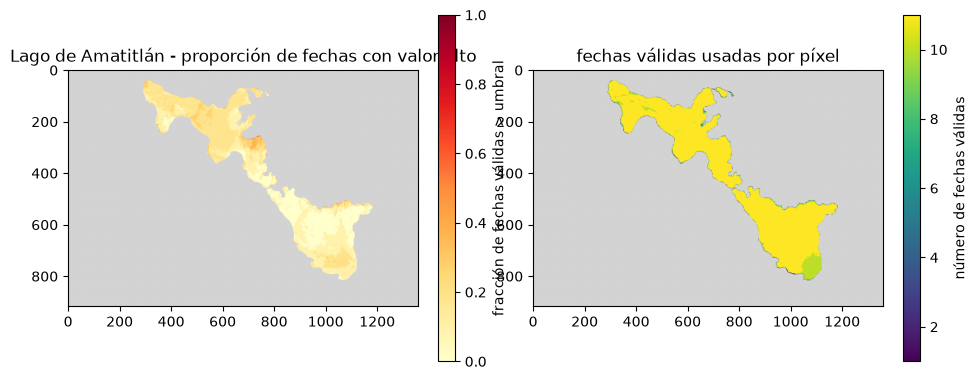

In [6]:
fig = ae.plot_persistence_map('amatitlan', resultados_persistencia['amatitlan'])
plt.show()

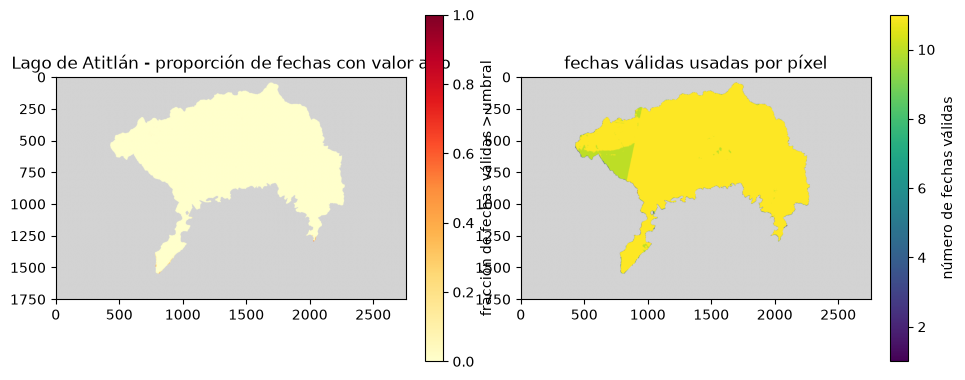

In [7]:
fig = ae.plot_persistence_map('atitlan', resultados_persistencia['atitlan'])
plt.show()

## 5. Resumen por lago

Porcentaje del area valida del lago que tiene una proporcion de fechas
altas mayor a 0 (zona con al menos un episodio de valor alto en el
periodo) y mayor o igual a 0.5 (zona con valor alto en la mitad o mas de
sus fechas validas): una aproximacion a "cuanta area es persistentemente
alta" en vez de solo "cuanta area tuvo un pico aislado".

In [8]:
resumen_persistencia = []
for lago in LAGOS:
    proporcion = resultados_persistencia[lago]['proporcion_alto']
    con_dato = np.isfinite(proporcion)
    total_con_dato = int(con_dato.sum())
    alguna_vez_alto = int((con_dato & (proporcion > 0)).sum())
    persistente = int((con_dato & (proporcion >= 0.5)).sum())
    resumen_persistencia.append({
        'lago': lago,
        'pixeles_con_dato_suficiente': total_con_dato,
        'pct_area_con_algun_episodio_alto': round(100 * alguna_vez_alto / total_con_dato, 3) if total_con_dato else 0.0,
        'pct_area_persistente_50pct_fechas': round(100 * persistente / total_con_dato, 3) if total_con_dato else 0.0,
    })

display(pd.DataFrame(resumen_persistencia))

,lago,pixeles_con_dato_suficiente,pct_area_con_algun_episodio_alto,pct_area_persistente_50pct_fechas
0,atitlan,1224417,0.172,0.006
1,amatitlan,145774,72.365,0.148


## 6. Interpretacion (hipotesis, no prueba de causa)

Una zona con proporcion alta de fechas por encima del umbral indica una
tendencia persistente en ese punto del lago a lo largo del periodo
observado (11 fechas irregulares, no una serie continua), no la
confirmacion de una causa especifica (aporte de nutrientes, corrientes,
profundidad, uso del suelo cercano). Esa interpretacion ambiental mas
completa, cruzando persistencia con distribuciones y correlaciones,
corresponde al analisis conjunto de los dos lagos.

## 7. Resultado del ejercicio

- Proporcion de fechas altas y conteo de fechas validas calculados por
  pixel para ambos lagos, exportados como GeoTIFF en
  `data/processed/analisis_espacial/<lago>/persistencia/`.
- Mapas de persistencia (dos paneles) guardados en
  `results/maps/<lago>_persistencia_cianobacteria.png`.
- El denominador de la proporcion es variable por pixel (numero de fechas
  validas de ese pixel, minimo `MIN_FECHAS_VALIDAS = 3`), documentado en
  `codebook.md`.
- El resumen de la seccion 5 cuantifica cuanta area del lago tuvo algun
  episodio alto frente a cuanta area fue persistentemente alta (>=50% de
  sus fechas validas), insumo directo para la comparacion entre lagos.